In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import time

In [49]:
#from modules.data_collection import scrape
#scrape()

In [50]:
data1 = pd.read_csv("data/products1.csv")
data2 = pd.read_csv("data/products2.csv")

In [51]:
data1.head()

,Name,Price,Category
0,Spaghetti 500g EXTRA,"90,00 د.ج",Pâtes et Couscous
1,Spaghetti 500g EXTRA,"90,00 د.ج",Pâtes et Couscous
2,FUSILLI 500g Garrido,"115,00 د.ج",Pâtes et Couscous
3,FUSILLI 500g Garrido,"115,00 د.ج",Pâtes et Couscous
4,NIDI 500G محبوبة,"180,00 د.ج",Pâtes et Couscous


In [52]:
data1.duplicated().sum()

np.int64(189)

In [53]:
data1.isna().sum()

Name        0
Price       0
Category    0
dtype: int64

In [54]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      378 non-null    str  
 1   Price     378 non-null    str  
 2   Category  378 non-null    str  
dtypes: str(3)
memory usage: 9.0 KB


In [55]:
data1.describe()


,Name,Price,Category
count,378,378,378
unique,189,63,8
top,Spaghetti 500g EXTRA,"95,00 د.ج",Pâtes et Couscous
freq,2,34,138


In [56]:
# drop the duplicates in data1
data1.drop_duplicates(inplace=True)

In [57]:
data1.describe()

,Name,Price,Category
count,189,189,189
unique,189,63,8
top,Spaghetti 500g EXTRA,"95,00 د.ج",Pâtes et Couscous
freq,1,17,69


In [58]:
# clean the price field (to convert it from str to float)
data1["Price"] = (
    data1["Price"]
    .astype(str)
    .str.replace("د.ج", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
)

In [59]:
data1.head()

,Name,Price,Category
0,Spaghetti 500g EXTRA,90.00,Pâtes et Couscous
2,FUSILLI 500g Garrido,115.00,Pâtes et Couscous
4,NIDI 500G محبوبة,180.00,Pâtes et Couscous
6,GNOCCHETTI 500G البركة,110.00,Pâtes et Couscous
8,CHAKHCHOUKHA 500G البركة,110.00,Pâtes et Couscous


In [60]:
data1.tail()

,Name,Price,Category
368,BISCUITS MAXON XL CACAO 400G,180.00,Epicerie-Sucree
370,BISCUITS MEGA DREAM CHOCOLAT 320G,110.00,Epicerie-Sucree
372,BISCUITS MEGA DREAM FRAISE 320G,110.00,Epicerie-Sucree
374,PATE A TARTINER OPTILLA 700G,470.00,Epicerie-Sucree
376,CHOCOLAT POUDRE NOVA 500G,325.00,Epicerie-Sucree


In [61]:
# convert the price to numeric values
data1["Price"] = pd.to_numeric(data1["Price"], errors="coerce")

In [62]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 376
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      189 non-null    str    
 1   Price     182 non-null    float64
 2   Category  189 non-null    str    
dtypes: float64(1), str(2)
memory usage: 4.6 KB


In [63]:
data2.head()

,Name,Price,Category
0,Ail,900 DA,Fruits et Légumes
1,Ail Rouge en Vrac,60 DA – 600 DA,Fruits et Légumes
2,Ananas,"120 DA – 1,200 DA",Fruits et Légumes
3,Anchois Vrac,"250 DA – 2,500 DA",Fruits et Légumes
4,Artichaut 1kg,250 DA,Fruits et Légumes


In [64]:
data2.tail()

,Name,Price,Category
137,Semoule Fine Mama 5Kg,390 DA,Semoulerie et Farine
138,Semoule Grosse Mama 1KG,100 DA,Semoulerie et Farine
139,Semoule Grosse Mama 2kg,170 DA,Semoulerie et Farine
140,Semoule Moyenne Mama 1kg,90 DA,Semoulerie et Farine
141,Semoule Moyenne Mama 2kg,235 DA,Semoulerie et Farine


In [65]:
data2.describe()

,Name,Price,Category
count,142,142,142
unique,130,77,3
top,Pomme Jaune Super,"1,200 DA",Fruits et Légumes
freq,2,9,96


In [66]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      142 non-null    str  
 1   Price     142 non-null    str  
 2   Category  142 non-null    str  
dtypes: str(3)
memory usage: 3.5 KB


In [67]:
# drop duplicates in data2
data2.drop_duplicates(inplace=True)

In [68]:
data2.describe()

,Name,Price,Category
count,130,130,130
unique,130,77,3
top,Ail,"1,200 DA",Fruits et Légumes
freq,1,9,84


In [69]:
# clean the price field
data2["Price"] = (
    data2["Price"]
    .astype(str)
    .str.replace("DA", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
)

In [70]:
data2.head()

,Name,Price,Category
0,Ail,900,Fruits et Légumes
1,Ail Rouge en Vrac,60 –600,Fruits et Légumes
2,Ananas,120 –1200,Fruits et Légumes
3,Anchois Vrac,250 –2500,Fruits et Légumes
4,Artichaut 1kg,250,Fruits et Légumes


In [71]:
def convert_value(val):
    if pd.isna(val):
        return np.nan
        
    val = val.replace("–", "-")
    
    if "-" in val:
        parts = val.split("-")
        try:
            nums = [float(p) for p in parts if p != ""]
            return sum(nums) / len(nums)
        except:
            return np.nan
    try:
        return float(val)
    except:
        return np.nan
"""
    convert the price to numeric values (float) and for those who are represented by intervals
    we compute them by the mean
"""
data2["Price"] = data2["Price"].apply(convert_value)

In [72]:
data2.head()

,Name,Price,Category
0,Ail,900.0,Fruits et Légumes
1,Ail Rouge en Vrac,330.0,Fruits et Légumes
2,Ananas,660.0,Fruits et Légumes
3,Anchois Vrac,1375.0,Fruits et Légumes
4,Artichaut 1kg,250.0,Fruits et Légumes


In [73]:
data2.info()

<class 'pandas.DataFrame'>
Index: 130 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      130 non-null    str    
 1   Price     130 non-null    float64
 2   Category  130 non-null    str    
dtypes: float64(1), str(2)
memory usage: 4.1 KB


In [74]:
# concatenate data1 and data2
data = pd.concat([data1, data2], axis=0)
data.describe()

,Price
count,312.000000
mean,273.958333
std,305.327590
min,25.000000
25%,95.000000
50%,165.000000
75%,296.250000
max,1925.000000


In [75]:
data.info()

<class 'pandas.DataFrame'>
Index: 319 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      319 non-null    str    
 1   Price     312 non-null    float64
 2   Category  319 non-null    str    
dtypes: float64(1), str(2)
memory usage: 10.0 KB


In [76]:
# drop the nan rows in the data (since they are only 7 rows)
data.dropna(inplace=True)

In [77]:
data.info()

<class 'pandas.DataFrame'>
Index: 312 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      312 non-null    str    
 1   Price     312 non-null    float64
 2   Category  312 non-null    str    
dtypes: float64(1), str(2)
memory usage: 9.8 KB


In [78]:
import re

In [79]:
# a function that extracts the quantity from the name with regex (regular expressions)
def extract_quantity(name, category):
    n = name.lower()
    # fruits & vegetables -> always per kg
    if category in ('Fruits et Légumes', 'Fruits Secs'):
        m = re.search(r'(\d+)\s*kg\b', n)
        if m:
            return f"{int(m.group(1)) * 1000} g"
        return "1000 g"
    # drinks -> convert to ml
    if category == 'Boisson':
        m = re.search(r'(\d+)\s*cl\b', n)
        if m:
            return f"{int(m.group(1)) * 10} ml"
        m = re.search(r'(\d+(?:[.,]\d+)?)\s*l\b', n)
        if m:
            return f"{int(float(m.group(1)) * 1000)} ml"
    # everything else -> look for g or kg in name
    m = re.search(r'(\d+)\s*g\b', n)
    if m:
        return f"{m.group(1)} g"
    m = re.search(r'(\d+)\s*kg\b', n)
    if m:
        return f"{int(m.group(1)) * 1000} g"
    return np.nan

data['Quantity'] = data.apply(
    lambda row: extract_quantity(row['Name'], row['Category']), axis=1
)

In [80]:
data.isna().sum()

Name         0
Price        0
Category     0
Quantity    27
dtype: int64

In [81]:
# then I have assigned qunatitites manually for products that does'nt contain quantities in their names (23 product)
data = pd.read_csv("data/products_manually_modified.csv")

In [82]:
data.isna().sum()

Name        0
Price       0
Category    0
Quantity    4
dtype: int64

In [83]:
# drop the 4 products that I didn't find their quantities
data.dropna(inplace=True)

In [84]:
# add nutritional unit field
data['Nutritional Unit'] = data['Quantity'].apply(
    lambda q: 'per 100 ml' if 'ml' in str(q) else 'per 100 g'
)

In [85]:
# from nutrition_db we map each product to it's nutritional unit
# produce_name_map is a dictionary that maps fruits and vegetables to their values
# here the order of mapping matters 
from data.nutrition_data import NUTRITION_DB, PRODUCE_NAME_MAP
def map_product_to_key(row):
    name = str(row['Name']).lower()
    cat  = str(row['Category'])

    if "confiture" in name:       return 'jam'
    if any(x in name for x in ["gazeuse", "slim", "selecto", "coca"]): return 'soda'
    if any(x in name for x in ["biscuits", "galette", "céréales"]):       return 'biscuits'
    for key in sorted(PRODUCE_NAME_MAP, key=len, reverse=True):
        if key in name:
            return PRODUCE_NAME_MAP[key]
    if "couscous" in name:        return 'couscous'
    if cat == 'Pâtes et Couscous': return 'dry_pasta'
    if any(x in name for x in ["candy choco", "chocolat"]): return 'chocolate_milk'
    if "lait" in name:
        return 'skim_milk' if any(x in name for x in ["ecreme", "silhouette"]) else 'whole_milk'
    if "margarine" in name:       return 'margarine'
    if "fromage"   in name:       return 'processed_cheese'
    if "riz"       in name:       return 'rice'
    if "lentille"  in name:       return 'lentils'
    if "pois chiche" in name:     return 'chickpeas'
    if "farine"    in name:       return 'flour'
    if "semoule"   in name:       return 'semolina'
    if "sucre"     in name:       return 'sugar'
    if "thon" in name:
        if "tomate"  in name:     return 'tuna_tomato'
        return 'tuna_natural' if "naturel" in name else 'tuna_in_oil'
    if "huile" in name or cat == 'Huiles et Vinaigre':
        if "vinaigre"   in name:  return 'vinegar'
        if "mayonnaise" in name:  return 'mayonnaise'
        return 'oil'
    if any(x in name for x in ["gaufrette", "gullon"]): return 'biscuits'
    if "pois cassés" in name:     return 'split_peas'
    if any(x in name for x in ["cafe", "café"]):  return 'coffee'
    if any(x in name for x in ["haraissa", "hrouss", "hrissa", "harissa"]): return 'harissa'
    if "haricot" in name and cat == "Légumes Secs": return 'kidney_beans'
    if "tartiner" in name:        return 'spread'

    TOMATO_FRESH_RE = re.compile(r'^(tomate)$')
    if "tomate" in name:
        if TOMATO_FRESH_RE.match(name):
            return 'tomato'
        else:
            return 'tomato_paste'
    return 'other'

data['Nutri_Key'] = data.apply(map_product_to_key, axis=1)

nutri_cols = ['Calories (g)', 'Protein (g)', 'Total_Fat (g)', 'Saturated_Fat (g)', 'Carbohydrates (g)', 'Sugar (g)', 'Fiber (g)', 'Sodium (mg)']

for i, col in enumerate(nutri_cols):
    data[col] = data['Nutri_Key'].map(lambda x: NUTRITION_DB.get(x, NUTRITION_DB['other'])[i])
# for the products that I didn't find their nutritional values i imputed them with the mean of their categry porducts nutritional values
data[nutri_cols] = data.groupby('Category')[nutri_cols].transform(lambda x: x.fillna(x.mean()))
# drop the nutri_key field
data.drop(columns=['Nutri_Key'], inplace=True)

In [86]:
data.isna().sum()

Name                 0
Price                0
Category             0
Quantity             0
Nutritional Unit     0
Calories (g)         0
Protein (g)          0
Total_Fat (g)        0
Saturated_Fat (g)    0
Carbohydrates (g)    0
Sugar (g)            0
Fiber (g)            0
Sodium (mg)          0
dtype: int64

In [87]:
# export the products data
data.insert(0, "PID", np.arange(1, len(data) + 1))
data.to_csv("data/products.csv", index=False, encoding="utf-8-sig")

In [88]:
recipes_header = [
    "RID",
    "Name",
    "type", # (Breakfast, lunch, dinner)
    "Category", # (Vegitarian, chicken etc...)
    "total_price", # calculated 
    "provided_calories" # calculated
]
recipes_data = pd.DataFrame(columns = recipes_header)

recipe_ingredient_header = [
    "PID", # from products data
    "RID", # from recipes data
    "Quantity"
]
recipe_ingredient_data = pd.DataFrame(columns = recipe_ingredient_header)

recipes_data.to_csv("data/recipes.csv", index=False, encoding="utf-8-sig")
recipe_ingredient_data.to_csv("data/recipe_ingredient.csv", index=False, encoding="utf-8-sig")

## Recipe Consolidation Workflow - PID-Based System

### Instructions :

1. **Get the template**: Copy `data/recipe_template.csv` into data/recipes_input and rename it to 'your-name.csv'
2. **Look up PIDs**: Find product PIDs in `data/products.csv` for each ingredient you want to use
3. **Fill in your recipes**: Replace PIDs and quantities with your own recipes

you can run the consolidation cell bellow this to integrate your recipes to the data.

###  CSV Format:

```
Name,Type,Category,PIDs,Quantities
Breakfast Omelette,Breakfast,Vegetarian,"3;191;200;162;152","3;100 g;50 g;15 ml;1 g"
```

- **Name**: Recipe name
- **Type**: Breakfast, Lunch, or Dinner
- **Category**: Vegetarian, Non-Vegetarian, Vegan, etc.
- **PIDs**: Semicolon-separated product IDs (from data/products.csv)
- **Quantities**: Semicolon-separated quantities with units (e.g., "100 g", "15 ml", "3")

In [89]:
from modules.recipe_consolidation import run_consolidation

# Run the consolidation process
recipes_df, recipe_ingredients_df = run_consolidation(
    products_csv="data/products.csv",
    recipes_input_dir="data/recipes_input"
)

RECIPE CONSOLIDATION PROCESS

1. Loading individual recipe files...
Found 4 recipe file(s)
   Loaded 215 recipes

2. Calculating totals for each recipe...

3. Generating output CSVs...

4. Validation Report:
   ✓ Recipes consolidated: 215
   ⚠ Warnings: 0
   ✗ Errors: 0

5. Export Complete:
   ✓ data/recipes.csv (215 recipes)
   ✓ data/recipe_ingredient.csv (962 items)


In [90]:
# View consolidated recipes
print("CONSOLIDATED RECIPES")
print(recipes_df.head(3))
print("\nRECIPE INGREDIENTS MAPPING")
print(recipe_ingredients_df.head(3))

CONSOLIDATED RECIPES
   RID                  Name       type     Category  total_price  \
0    1     Chicken Rice Bowl      Lunch  Gluten-Free        97.73   
1    2  Gluten-Free Omelette  Breakfast  Gluten-Free       487.59   
2    3       Tuna Salad Bowl      Lunch  Gluten-Free       213.99   

   provided_calories  provided_protein  provided_fat  provided_carbs  
0             987.29            241.20         71.33          649.99  
1             403.59            166.04        209.52           15.31  
2             296.81            126.53        112.32           70.29  

RECIPE INGREDIENTS MAPPING
   PID  RID Quantity
0  309    1    150 g
1   81    1    200 g
2  228    1    10 ml


In [91]:
recipes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RID                215 non-null    int64  
 1   Name               215 non-null    str    
 2   type               215 non-null    str    
 3   Category           215 non-null    str    
 4   total_price        215 non-null    float64
 5   provided_calories  215 non-null    float64
 6   provided_protein   215 non-null    float64
 7   provided_fat       215 non-null    float64
 8   provided_carbs     215 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 15.2 KB


In [92]:
recipes_df.describe()

,RID,total_price,provided_calories,provided_protein,provided_fat,provided_carbs
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,108.000000,254.514419,739.322837,183.008558,240.881767,316.753116
std,62.209324,233.045841,661.556398,180.764981,301.463918,367.416285
min,1.000000,22.320000,127.040000,5.120000,4.500000,5.400000
25%,54.500000,90.975000,361.420000,108.520000,116.010000,34.865000
50%,108.000000,167.030000,561.840000,159.810000,167.130000,186.080000
75%,161.500000,388.425000,942.235000,221.220000,279.945000,572.960000
max,215.000000,1502.540000,6559.200000,2246.300000,3185.100000,2884.000000


# Transition Model

In [93]:
NUTRI_PREFERENCE_MAP = {
    "maintain":       {"protein": 0.30, "fat": 0.25, "carbs": 0.45},
    "gain":   {"protein": 0.40, "fat": 0.25, "carbs": 0.35},
    "loss":       {"protein": 0.25, "fat": 0.35, "carbs": 0.40},
}

def Gettransitionmodel(recipes_df):
    result = {}

    for _, row in recipes_df.iterrows():
        meal_type = row["type"]
        meal_name = row["Name"]

        meal_info = (
            row["Category"],
            row["total_price"],
            row["provided_calories"],
            row["provided_protein"],
            row["provided_carbs"],
            row["provided_fat"]
        )
        if meal_type not in result:
           result[meal_type] = {}

        result[meal_type][meal_name] = meal_info

    return result

TransitionModel = Gettransitionmodel(recipes_df)


# Genetic Algorithms

In [ ]:

# helper functions
def resolve_nutri_preference(preference_str):
    key = preference_str.strip().lower()
    if key not in NUTRI_PREFERENCE_MAP:
        valid = ", ".join(NUTRI_PREFERENCE_MAP.keys())
        raise ValueError(f"Unknown preference '{preference_str}'. Valid options: {valid}")
    return NUTRI_PREFERENCE_MAP[key]
def diversity_penalty_per_week(state):
    penalty = 0
    days_per_week = 7
    meals_per_day = 3

    for start in range(0, len(state), days_per_week):
        week = state[start:start + days_per_week]

        week_meals = [meal for day in week for meal in day]

        counts = {}
        for meal in week_meals:
            counts[meal] = counts.get(meal, 0) + 1

        for meal, count in counts.items():
            if count > 2:
                penalty += (count - 2)
    return penalty / (len(state) * meals_per_day)

def crossover_and_mutation(population,problem):
    childs = []
    model = problem.transitionmodel
    for i in range(len(population)):
        for j in range(i+1,len(population)):
            cutoff = random.randrange(1,29)
            parent_a = population[i][0]
            parent_b = population[j][0]
            child_a = parent_a[:cutoff] + parent_b[cutoff:]
            child_b = parent_b[:cutoff] + parent_a[cutoff:]
            random_lunch_a = random.choice(list(model['Lunch'].keys()))
            random_lunch_b = random.choice(list(model['Lunch'].keys()))
            random_pos_a  = random.randrange(30)
            random_pos_b  = random.randrange(30)
            t1 =   [child_a[random_pos_a][0],random_lunch_a, child_a[random_pos_a][2]]
            t2 =  [child_b[random_pos_b][0],random_lunch_b, child_b[random_pos_b][2]]
            child_a[random_pos_a] = tuple(t1) 
            child_b[random_pos_b] = tuple(t2) 
            childs.append((child_a,problem.fitness_function(child_a)))
            childs.append((child_b,problem.fitness_function(child_b)))
    return childs
# GA problem definition
class GAProblem:
    def __init__(self, recipes_df, total_price, tdee, nutri_preference_str="maintain"):
        self.size = 90 # we did not use this at all occurance = 1
        self.total_price = total_price
        self.tdee = tdee
        self.transitionmodel = TransitionModel
        prefs = resolve_nutri_preference(nutri_preference_str)
        self.target_protein_g = tdee * prefs["protein"]
        self.target_fat_g     = tdee * prefs["fat"]
        self.target_carbs_g   = tdee * prefs["carbs"]
     
    def get_total_cost(self, state):
        total_cost = 0
        model = self.transitionmodel
        for day in state:
           total_cost += (
               model["Breakfast"][day[0]][1] +
               model["Lunch"][day[1]][1] +
               model["Dinner"][day[2]][1]
           )
        return total_cost
    
    
    def get_total_cal(self,state):
        day_calories = []
        model = self.transitionmodel
        tdee = self.tdee
        for day in state:
            day_cal = (
            model["Breakfast"][day[0]][2] +
            model["Lunch"][day[1]][2] +
            model["Dinner"][day[2]][2]
        )
            if day_cal > tdee * 1.1 or day_cal < tdee * 0.9:
                print(day_cal)
                print("Out of calories range")
            day_calories.append(day_cal)
        
        return sum(day_calories)
    

    def _macro_penalty_for_day(self, day):
        model = self.transitionmodel
        target_fat = self.target_fat_g
        target_protein = self.target_protein_g
        target_carbs = self.target_carbs_g
        actual_protein =  model["Breakfast"][day[0]][3] +  model["Dinner"][day[2]][3] +  model["Lunch"][day[1]][3]
        actual_carbs   = model["Breakfast"][day[0]][4] +  model["Dinner"][day[2]][4] +  model["Lunch"][day[1]][4]
        actual_fat   = model["Breakfast"][day[0]][5] +  model["Dinner"][day[2]][5] +  model["Lunch"][day[1]][5]  
        protein_dev = abs(actual_protein - target_protein) / target_protein
        fat_dev     = abs(actual_fat     - target_fat)     / target_fat
        carbs_dev   = abs(actual_carbs   - target_carbs)   / target_carbs
        return (protein_dev + fat_dev + carbs_dev) / 3
    

    def fitness_function(self, state):
        total_cost = self.get_total_cost(state)
        total_price = self.total_price
        cost_penalty = 0.5 + min((total_cost - total_price) / (total_cost), 0.5) if (total_price - total_cost) / (total_price) < 0 else (total_price - total_cost) / (total_price)
        tdee = self.tdee
        lower_bound = 0.9 * tdee
        upper_bound = 1.1 * tdee

        bad_days = 0
        total_macro_dev=0
        model = self.transitionmodel
        for day in state:
            day_calories = (
                model["Breakfast"][day[0]][2] +
                model["Lunch"][day[1]][2] +
                model["Dinner"][day[2]][2]
            )
            if day_calories != tdee:
                bad_days += 0.001
            if day_calories < lower_bound or day_calories > upper_bound:
                bad_days += 1
            total_macro_dev += self._macro_penalty_for_day(day)
        nutrition_penalty = bad_days / len(state)
        macro_penalty     = total_macro_dev / len(state)
        diversity_penalty = diversity_penalty_per_week(state)
        fitness = -(
            0.30 * cost_penalty +
            0.30* nutrition_penalty +
            0.1 * diversity_penalty +
            0.30* macro_penalty
        )
        return fitness
    
    
    def generate_random_state(self):
         model = self.transitionmodel
         breakfast_list = list(model['Breakfast'].keys())
         lunch_list = list(model['Lunch'].keys())
         dinner_list = list(model['Dinner'].keys())
         return [(random.choice(breakfast_list),
                  random.choice(lunch_list),
                  random.choice(dinner_list))
                    for _ in range(30)]
# GA Search
def GASearch(problem):
    # step 1 Selection:
    list_of_states = []
    for _ in range(80):
        state = problem.generate_random_state()
        fitness = problem.fitness_function(state)
        list_of_states.append((state,fitness))
    population = sorted(list_of_states, key=lambda x: x[1], reverse=True)[:20]
    # step 2 and 3 crossover and mutation
    for _ in range(200):
        population = sorted(population, key=lambda x: x[1], reverse=True)[:20]
        for state, fitness in population:
            if fitness > -0.015:
                return (state, fitness)
        population =  crossover_and_mutation(population,problem)
    best_candidate = sorted(population, key=lambda x: x[1], reverse=True)[:1]
    return best_candidate[0]

# GA Test

In [114]:
g = GAProblem(recipes_df,10000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(g.get_total_cost(solution))
print(g.get_total_cal(solution))

[('Algerian Chakchouka Eggs', 'Chicken Carrot Pea Bowl', 'Tuna Pasta'), ('Sardine Breakfast Plate', 'Broccoli Cauliflower Rice Bowl', 'Chicken Lentil Spinach Dinner'), ('Potato Onion Omelette DZ', 'Chicken Carrot Pea Bowl', 'Couscous Seffa'), ('Lentil Egg Breakfast Bowl', 'Lentil Spinach Lunch Soup', 'Chicken Mchermel'), ('Banana Almond Raib Bowl', 'Couscous Poulet Legumes', 'Merlan Lemon Olive Plate'), ('Baghrir', 'Chicken Lentil Power Bowl', 'Daurade Zucchini Olive Dinner'), ('Potato Onion Omelette DZ', 'Lentil Spinach Lunch Soup', 'Sardine Rice Coriander Dinner'), ('Shrimp Egg Herb Scramble', 'Rice with Peas and Carrots', 'Chicken Lentil Spinach Dinner'), ('Harissa Egg Scramble', 'Cucumber Olive Salad', 'Vegetable Soup'), ('Gluten-Free Omelette', 'Chicken Rice Bowl', 'Beef Pepper Stir Fry'), ('Beef Egg Breakfast Bowl', 'Chicken Carrot Pea Bowl', 'Couscous Seffa'), ('Vegetable Chakchouka', 'Couscous with Vegetables', 'Shrimp Brocculi Stir Fry'), ('Egg White Veggie Wrap', 'Lentil Vege

# GA Visualizations

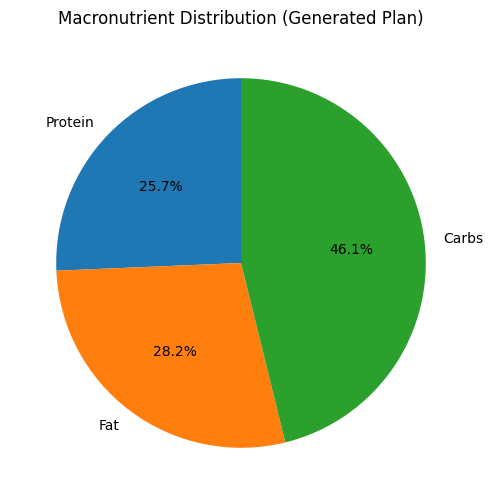

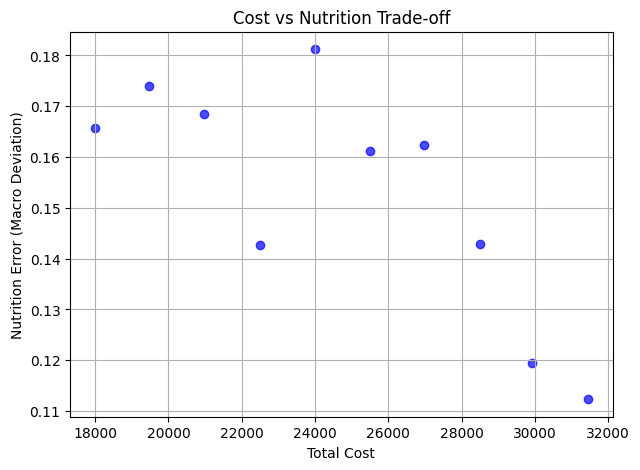

In [115]:

def get_macro_nutrition(transitionmodel, state): # we have two of this one for visulaization and one for the fitness 
    protein_v = 0
    fat_v = 0
    carbs_v = 0
    total_cal = 0
    for day in state:
        total_cal += transitionmodel["Breakfast"][day[0]][2] + transitionmodel["Lunch"][day[1]][2] + transitionmodel["Dinner"][day[2]][2]
        protein_v += transitionmodel["Breakfast"][day[0]][3] + transitionmodel["Lunch"][day[1]][3] + transitionmodel["Dinner"][day[2]][3]
        fat_v     +=transitionmodel["Breakfast"][day[0]][5] + transitionmodel["Lunch"][day[1]][5] + transitionmodel["Dinner"][day[2]][5]
        carbs_v   += transitionmodel["Breakfast"][day[0]][4] + transitionmodel["Lunch"][day[1]][4] + transitionmodel["Dinner"][day[2]][4]
    return [protein_v / total_cal, fat_v / total_cal, carbs_v / total_cal]

def macro_error(meals,state): # we have two also in this we use it in the visualization,fitness,greedy,A*
    macros = get_macro_nutrition(meals,state)

    target = [0.25, 0.35, 0.4]  # example , we can take it from the problem formulation

    error = sum(abs(macros[i] - target[i]) for i in range(3))

    return error

def get_axis_plot(meals):
     costs = []
     errors = []
     i = 18000
     for _ in range(10):  # 30 different solution
        g = GAProblem(recipes_df,i,2200)
        solution,_ = GASearch(g)
        cost = g.get_total_cost(solution)
        error = macro_error(meals,solution)
        i += 1500 
        costs.append(cost)
        errors.append(error)
     return costs,errors

meals_details = TransitionModel # we caluclate for each prblem except the CSP
labels = ['Protein', 'Fat', 'Carbs']
values = get_macro_nutrition(meals_details,solution)
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Macronutrient Distribution (Generated Plan)')
plt.show()
x_axis,y_axis = get_axis_plot(meals_details)
plt.figure(figsize=(7,5))
plt.scatter(x_axis, y_axis, color='blue', alpha=0.7)
plt.xlabel("Total Cost")
plt.ylabel("Nutrition Error (Macro Deviation)")
plt.title("Cost vs Nutrition Trade-off")
plt.grid(True)
plt.show()


# A* and Greedy

# Node Class

In [97]:
class MealPlannerState:
    def __init__(self, day_number, meal_type, meal, remaining_budget, today_calorie_use, today_protein_use, today_carbs_use, today_fat_use, used_meals = None):
        self.day = day_number
        self.meal_type = meal_type
        self.meal = meal
        self.remaining_budget = remaining_budget
        self.today_calorie_use = today_calorie_use
        self.today_protein_use = today_protein_use
        self.today_carbs_use = today_carbs_use
        self.today_fat_use = today_fat_use
        self.used_meals = used_meals
        
    def __eq__(self, other):
        return isinstance(other, MealPlannerState) and \
            self.day == other.day and \
            self.meal_type == other.meal_type and \
            self.meal == other.meal

    def __hash__(self):
        return hash((self.day, self.meal_type, self.meal))

class Node:    
    def __init__(self, state, parent=None, action=None, cost=0, heuristic=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.g = (parent.g + cost) if parent else 0
        self.f = self.g + heuristic
        self.depth = 0 if parent is None else parent.depth + 1

    def path(self):
        node = self
        actions = []
        while node.parent is not None:
            actions.append(node.action)
            node = node.parent
        actions.reverse()
        return actions

    def __lt__(self, other):
        return self.f < other.f

    def __eq__(self, other):
        return isinstance(other, Node) and self.state == other.state

    def __hash__(self):
        return hash(self.state)


# Problem Class

In [98]:
class MealPlanningProblem:

    def __init__(self, transition_model, TDEE, total_budget, num_days=7, macroNutri_preference="maintain"):
        self.transition_model = transition_model
        self.total_budget = total_budget
        self.TDEE = TDEE
        self.num_days = num_days
        self.meals_per_day = 3  # Breakfast, Lunch, Dinner
        self.total_slots = num_days * self.meals_per_day
        self.meal_types = ['Breakfast', 'Lunch', 'Dinner']

        self.meal_type_weights = {
            'Breakfast': 0.25,
            'Lunch': 0.40,
            'Dinner': 0.35
        }

        self.consider_deviation = True

        self.macro_nutrients_ratios = NUTRI_PREFERENCE_MAP[macroNutri_preference]

        self.initial_state = MealPlannerState(0, 0, None, total_budget, 0, 0, 0, 0, set())
        
    def _get_remaining_days(self, state):
        current_slot = state.day * self.meals_per_day + state.meal_type + 1
        remaining_slots = self.total_slots - current_slot
        return math.ceil(remaining_slots / self.meals_per_day)

    def _calculate_totals(self, recipes_list):
        total_cost = 0
        total_calories = 0
        
        i = 0
        for meal_name in recipes_list:
            recipe = self.transition_model[self.meal_types[i]][meal_name]
            total_cost += recipe[1]
            total_calories += recipe[2]
            
            i = (i+1)%3

        return total_cost, total_calories

    def is_goal(self, node):
        state = node.state
        
        if state.day < self.num_days:
            return False
        
        recipes_chosen = node.path()
        
        if len(recipes_chosen) != self.total_slots:
            return False
        
        total_cost, total_calories = self._calculate_totals(recipes_chosen)
        
        goal_calories = self.TDEE * self.num_days
        calorie_tolerance = goal_calories * 0.1
        calories_ok = abs(total_calories - goal_calories) <= calorie_tolerance or not self.consider_deviation
        
        budget_ok = total_cost <= self.total_budget
        
        return calories_ok and budget_ok

    def expand_node(self, node, use_cost=True, use_heuristic=False):
        state = node.state
        
        if state.day >= self.num_days:
            return []
        
        children = []
        valid_actions = self.transition_model[self.meal_types[node.state.meal_type]]
        
        for meal_name in valid_actions:

            if meal_name in state.used_meals:
                continue

            recipe = self.transition_model[self.meal_types[node.depth%3]][meal_name]
            
            action_cost = self.calculate_cost(node.state, meal_name) if use_cost else 0
            
            new_meal_idx = (state.meal_type + 1) % self.meals_per_day
            new_day = state.day if new_meal_idx > 0 else state.day + 1
            new_remaining_budget = state.remaining_budget - recipe[1]
            new_calorie_use = 0 if new_meal_idx == 0 else state.today_calorie_use + recipe[2]
            new_protein_use = 0 if new_meal_idx == 0 else state.today_protein_use + recipe[3]
            new_carbs_use = 0 if new_meal_idx == 0 else state.today_carbs_use + recipe[4]
            new_fat_use = 0 if new_meal_idx == 0 else state.today_fat_use + recipe[5]
            
            if new_day % 15 == 0 and new_day != 0:
                new_used_meals = set({})
            else:
                new_used_meals = set(state.used_meals)

            new_used_meals.add(meal_name)
            
            new_state = MealPlannerState(new_day, new_meal_idx, meal_name, new_remaining_budget,
            new_calorie_use, new_protein_use, new_carbs_use, new_fat_use, new_used_meals)
            
            heuristic = self.calculate_heuristic(new_state) if use_heuristic else 0
            
            child = Node(new_state, parent=node, action=meal_name, cost=action_cost, heuristic=heuristic)
            children.append(child)
        
        return children

    def calculate_cost(self, state, meal_name=None):
        if meal_name is None:
            meal_name = state.meal
        
        if meal_name is None:
            return 0
        
        recipe = self.transition_model[self.meal_types[state.meal_type]][meal_name]
        meal_type = self.meal_types[state.meal_type]
        
        remaining_days = self._get_remaining_days(state)
        
        allocated_price = self.meal_type_weights[meal_type] * (state.remaining_budget / max(1, remaining_days))
        allocated_calories = self.meal_type_weights[meal_type] * self.TDEE 

        allocated_protein = self.meal_type_weights[meal_type] * self.TDEE * self.macro_nutrients_ratios["protein"]
        allocated_carbs = self.meal_type_weights[meal_type] * self.TDEE * self.macro_nutrients_ratios["carbs"]
        allocated_fat = self.meal_type_weights[meal_type] * self.TDEE * self.macro_nutrients_ratios["fat"]

        price_deviation = abs(recipe[1] - allocated_price)
        calorie_deviation = abs(recipe[2] - allocated_calories)
        protein_deviation = abs(recipe[3] - allocated_protein)
        carbs_deviation = abs(recipe[4] - allocated_carbs)
        fat_deviation = abs(recipe[5] - allocated_fat)

        normalized_price_dev = price_deviation / allocated_price if allocated_price > 0 else 0
        normalized_cal_dev = calorie_deviation / allocated_calories if allocated_calories > 0 else 0
        normalized_protein_dev = protein_deviation / allocated_protein if allocated_protein > 0 else 0
        normalized_carbs_dev = carbs_deviation / allocated_carbs if allocated_carbs > 0 else 0
        normalized_fat_dev = fat_deviation / allocated_fat if allocated_fat > 0 else 0

        total_cost = (normalized_price_dev + normalized_cal_dev + normalized_protein_dev + normalized_carbs_dev + normalized_fat_dev) / 5.0
        
        return total_cost


    def calculate_heuristic(self, state):
        remaining_slots = self.total_slots - (state.day * self.meals_per_day + state.meal_type)
        if remaining_slots <= 0:
            return 0

        calorie_gap = abs(state.today_calorie_use - self.TDEE) / self.TDEE
        protein_gap = abs(state.today_protein_use - (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["protein"])) / (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["protein"]) if (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["protein"]) > 0 else 0
        carbs_gap = abs(state.today_carbs_use - (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["carbs"])) / (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["carbs"]) if (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["carbs"]) > 0 else 0
        fat_gap = abs(state.today_fat_use - (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["fat"])) / (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["fat"]) if (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["fat"]) > 0 else 0

        return (calorie_gap + protein_gap + carbs_gap + fat_gap) / 4.0


# Search Class

### A*

In [99]:
import queue

class AstarSearch:
    def __init__(self,problem):
        self.problem = problem
        self.problem.consider_deviation = True
        self.frontier = queue.PriorityQueue()

        self.explored = set()

    def search(self):

        node = Node(self.problem.initial_state)
        self.frontier.put(node)
        
        while True:
            if self.frontier.empty():
                return None

            node = self.frontier.get()
            
            if self.problem.is_goal(node):
                solution = self._get_solution_path(node)
                return solution

            self.explored.add(node.state)

            children = self.problem.expand_node(node, True, True)

            for child in children:
                if child.state not in self.explored and child not in self.frontier.queue:
                    self.frontier.put(child)

    def _get_solution_path(self, solution_node):
        path = solution_node.path()
        path = [tuple([
                path[i],
                path[i+1],
                path[i+2]
            ]) for i in range(0, len(path), 3)]

        return path


### Greedy

In [100]:
class GreedySearch:
    def __init__(self,problem):
        self.problem = problem
        self.problem.consider_deviation = False
        self.frontier = queue.PriorityQueue()

        self.explored = set()

    def search(self):

        node = Node(self.problem.initial_state)
        self.frontier.put(node)
        
        while True:
            if self.frontier.empty():
                return None

            node = self.frontier.get()
            
            if self.problem.is_goal(node):
                solution = self._get_solution_path(node)
                return solution

            self.explored.add(node.state)

            children = self.problem.expand_node(node, False, True)

            for child in children:
                if child.state not in self.explored and child not in self.frontier.queue:
                    self.frontier.put(child)

    def _get_solution_path(self, solution_node):
        path = solution_node.path()
        path = [tuple([
                path[i],
                path[i+1],
                path[i+2]
            ]) for i in range(0, len(path), 3)]

        return path

# Run Test

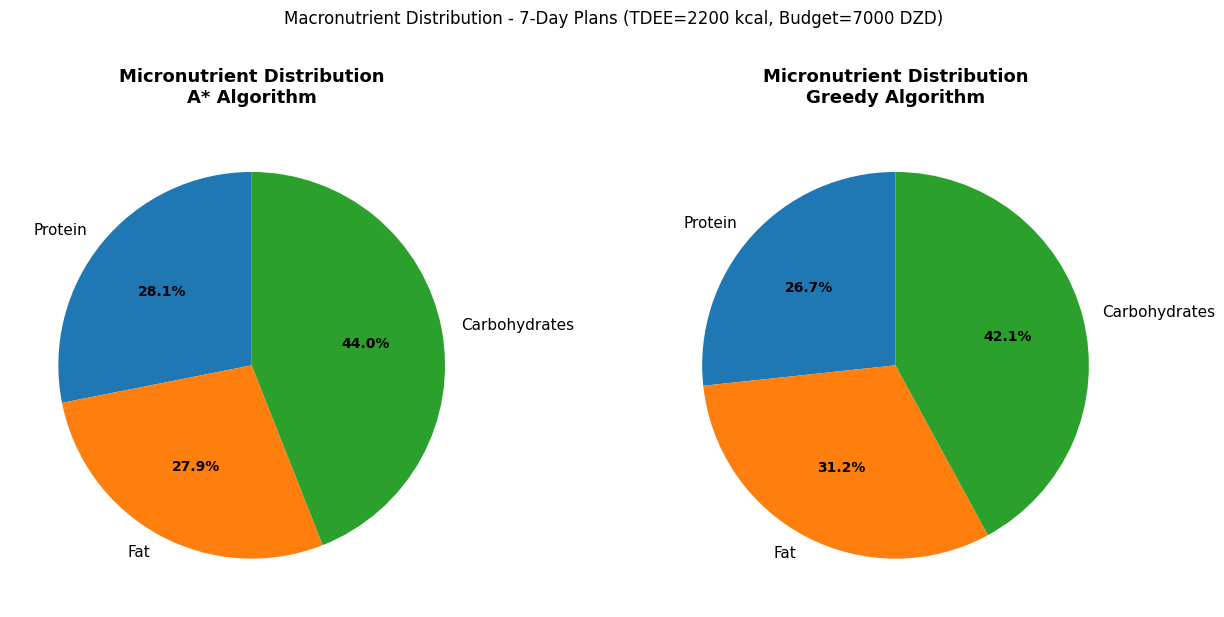

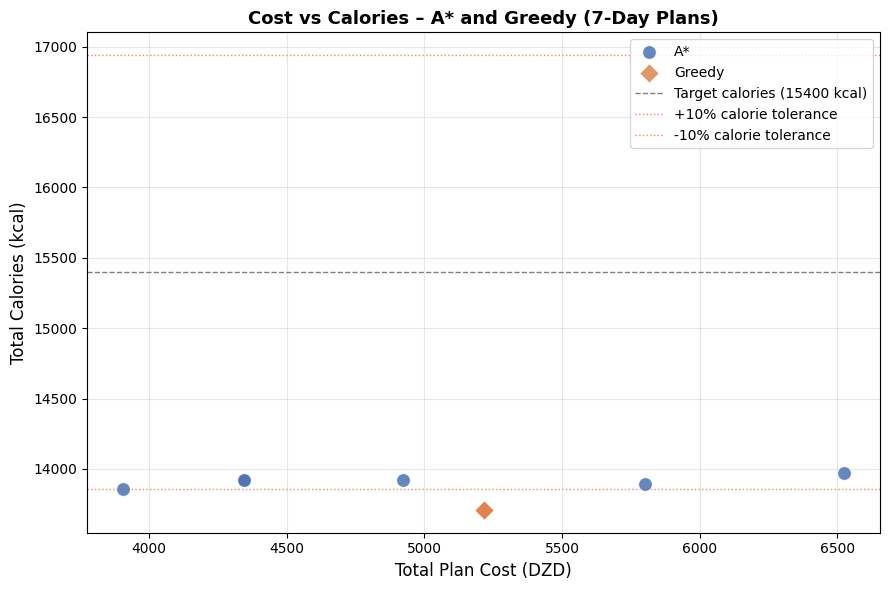

In [101]:
def get_solution_nutrition(solution, TransitionModel):
    total_cost = 0
    total_calories = 0
    total_protein = 0
    total_fat = 0
    total_carbs = 0

    for day_meals in solution:
        breakfast, lunch, dinner = day_meals
        for slot, meal in zip(["Breakfast", "Lunch", "Dinner"], [breakfast, lunch, dinner]):
            info = TransitionModel[slot][meal]
            # info = (Category, cost, kcal, protein, carbs, fat)
            total_cost     += info[1]
            total_calories += info[2]
            total_protein  += info[3]
            total_carbs    += info[4]
            total_fat      += info[5]

    return total_cost, total_calories, total_protein, total_carbs, total_fat


def run_and_collect(TDEE, budget, days, strat):
    problem = MealPlanningProblem(TransitionModel, TDEE, budget, days)
    S = AstarSearch(problem) if strat == "A*" else GreedySearch(problem)
    solution = S.search()
    if solution is None:
        return None
    cost, cal, prot, carbs, fat = get_solution_nutrition(solution, TransitionModel)
    return solution, cost, cal, prot, carbs, fat


TDEE_VIZ   = 2200
BUDGET_VIZ = 7000
DAYS_VIZ   = 7

astar_result  = run_and_collect(TDEE_VIZ, BUDGET_VIZ, DAYS_VIZ, "A*")
greedy_result = run_and_collect(TDEE_VIZ, BUDGET_VIZ, DAYS_VIZ, "greedy")

# Pie Charts Micronutrient Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
labels     = ["Protein", "Fat", "Carbohydrates"]
explode    = (0.04, 0.04, 0.04)

for ax, result, title in zip(
    axes,
    [astar_result, greedy_result],
    ["A* Algorithm", "Greedy Algorithm"]
):
    if result is None:
        ax.set_title(f"{title}\n(No solution found)", fontsize=13)
        continue
    _, cost, cal, prot, carbs, fat = result
    values = [prot, fat, carbs]
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 11},
    )
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight("bold")
    ax.set_title(f"Micronutrient Distribution\n{title}", fontsize=13, fontweight="bold", pad=15)

plt.suptitle(
    f"Macronutrient Distribution - {DAYS_VIZ}-Day Plans (TDEE={TDEE_VIZ} kcal, Budget={BUDGET_VIZ} DZD)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


# Scatter Plot Cost vs Nutrition
budgets = list(range(5000, 16000, 2000))   # vary budget to get different operating points

costs_astar, cals_astar     = [], []
costs_greedy, cals_greedy   = [], []

for bud in budgets:
    for strat, cost_list, cal_list in [
        ("A*",     costs_astar,  cals_astar),
        ("greedy", costs_greedy, cals_greedy),
    ]:
        res = run_and_collect(TDEE_VIZ, bud, DAYS_VIZ, strat)
        if res is not None:
            _, cost, cal, *_ = res
            cost_list.append(cost)
            cal_list.append(cal)
        else:
            cost_list.append(None)
            cal_list.append(None)

# Filter out None
def clean(costs, cals):
    pairs = [(c, k) for c, k in zip(costs, cals) if c is not None and k is not None]
    if not pairs:
        return [], []
    return zip(*pairs)

ca, ka = clean(costs_astar, cals_astar)
cg, kg = clean(costs_greedy, cals_greedy)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(list(ca), list(ka), color="#4C72B0", s=100, alpha=0.85, edgecolors="white",
           linewidths=0.8, label="A*", zorder=3)
ax.scatter(list(cg), list(kg), color="#DD8452", s=100, alpha=0.85, edgecolors="white",
           linewidths=0.8, marker="D", label="Greedy", zorder=3)

# Reference lines
ax.axhline(TDEE_VIZ * DAYS_VIZ,       color="gray", linestyle="--", linewidth=1,
           label=f"Target calories ({TDEE_VIZ*DAYS_VIZ} kcal)")
ax.axhline(TDEE_VIZ * DAYS_VIZ * 1.1, color="salmon", linestyle=":",  linewidth=1,
           label="+10% calorie tolerance")
ax.axhline(TDEE_VIZ * DAYS_VIZ * 0.9, color="salmon", linestyle=":",  linewidth=1,
           label="-10% calorie tolerance")

ax.set_xlabel("Total Plan Cost (DZD)", fontsize=12)
ax.set_ylabel("Total Calories (kcal)",  fontsize=12)
ax.set_title(
    f"Cost vs Calories – A* and Greedy ({DAYS_VIZ}-Day Plans)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

print("A* Result: ")
sol, cost, cal, prot, carb, fat = run_and_collect(2600, 7000, 7, "A*")

print(sol)
print(f"Cost: {cost}")
print(f"Calories: {cal}")
print(f"Protein: {prot}")
print(f"Carbs: {carb}")
print(f"Fat: {fat}")

print("\n\nGreedy search Result: ")
sol, cost, cal, prot, carb, fat = run_and_collect(2600, 7000, 7, "Greedy")

print(sol)
print(f"Cost: {cost}")
print(f"Calories: {cal}")
print(f"Protein: {prot}")
print(f"Carbs: {carb}")
print(f"Fat: {fat}")

A* Result: 
[('Egg Oat Protein Pancakes', 'Tuna Chickpea Mint Salad', 'Chicken Mchermel'), ('Protein peanaut butter Smoothie', 'Shrimp Rice Coriander Bowl', 'Tlitli Beef Dinner'), ('Oat Banana Pancake Bowl', 'Shrimp Green Bean Rice', 'Chorba Lentil Lamb'), ('Lentil Egg Breakfast Bowl', 'Rice & Egg Bowl', 'Beef Loubia Stew'), ('Banana Peanut Protein Smoothie', 'Tajine Zitoun', 'Chorba Vermicelle Beef'), ('Chickpea Egg Garlic Bowl', 'Shrimp Rice Bowl', 'Beef Mushroom Pasta'), ('Egg White Veggie Wrap', 'Tuna Rice Olive Bowl', 'Couscous Sardine Dinner')]
Cost: 6785.110000000001
Calories: 16489.850000000006
Protein: 4079.1099999999997
Carbs: 7879.6900000000005
Fat: 4569.03


Greedy search Result: 
[('Egg Oat Protein Pancakes', 'Merlan Green Bean Plate', 'Tastira'), ('Oat Banana Pancake Bowl', 'Shrimp Hmiss Bowl', 'Chorba Lentil Lamb'), ('Protein peanaut butter Smoothie', 'Lentil Spinach Lunch Soup', 'Eggplant Tomato Skillet'), ('Baghrir', 'Garlic Shrimp Bowl', 'Shrimp Tomato Garlic Pan'), (

# CSP

### User input

In [102]:
TDEE         = 2000    # target daily calories
DAILY_BUDGET = 1500    # DZD per day
DAYS         = 30
GOAL         = "maintain"

### Macro delta

In [103]:
def compute_macro_delta(day_meal_names, goal="maintain"):
    """
    day_meal_names: tuple/list of (breakfast_name, lunch_name, dinner_name)
    Reads nutrition from TransitionModel directly.
    Returns dict with actual, target, delta per macro, and a 0-1 penalty score.
    """
    slots  = ["Breakfast", "Lunch", "Dinner"]
    ratios = NUTRI_PREFERENCE_MAP[goal]

    actual_protein = sum(TransitionModel[slots[i]][day_meal_names[i]][3] for i in range(3))
    actual_carbs   = sum(TransitionModel[slots[i]][day_meal_names[i]][4] for i in range(3))
    actual_fat     = sum(TransitionModel[slots[i]][day_meal_names[i]][5] for i in range(3))

    # Convert calorie-ratio targets to grams
    target_protein_g = (TDEE * ratios["protein"]) / 4
    target_carbs_g   = (TDEE * ratios["carbs"])   / 4
    target_fat_g     = (TDEE * ratios["fat"])      / 9

    delta_protein = actual_protein - target_protein_g
    delta_carbs   = actual_carbs   - target_carbs_g
    delta_fat     = actual_fat     - target_fat_g

    penalty = (
        abs(delta_protein) / target_protein_g +
        abs(delta_carbs)   / target_carbs_g   +
        abs(delta_fat)     / target_fat_g
    ) / 3

    return {
        "actual": {"protein_g": actual_protein, "carbs_g": actual_carbs, "fat_g": actual_fat},
        "target": {"protein_g": target_protein_g, "carbs_g": target_carbs_g, "fat_g": target_fat_g},
        "delta":  {"protein_g": delta_protein,  "carbs_g": delta_carbs,  "fat_g": delta_fat},
        "penalty": min(penalty, 1.0)
    }

### Domain Building

In [104]:
def build_domains():
    """
    Builds initial domains from TransitionModel.
    Each domain entry is a meal_name string (consistent with TransitionModel keys).
    Pre-filters by: preference, per-slot calorie cap, and per-slot budget cap.
    """
    slot_calorie_share = {"Breakfast": 0.35, "Lunch": 0.40, "Dinner": 0.40}
    slot_budget_share  = {"Breakfast": 0.35, "Lunch": 0.40, "Dinner": 0.40}

    domains = {}
    for day in range(DAYS):
        for slot in ["Breakfast", "Lunch", "Dinner"]:
            cal_cap    = TDEE         * slot_calorie_share[slot]
            budget_cap = DAILY_BUDGET * slot_budget_share[slot]

            domains[(day, slot)] = [
                meal_name
                for meal_name, info in TransitionModel[slot].items()
                # info = (Category, cost, kcal, protein, carbs, fat)
                if info[2] <= cal_cap       # kcal within slot share
                and info[1] <= budget_cap    # cost within slot share
            ]
    return domains

### Constraints

In [105]:
def are_compatible(slot_i, meal_i_name, slot_j, meal_j_name,
                   third_min_kcal, third_max_kcal, third_min_cost):
    """
    Returns True if meal_i and meal_j can coexist on the same day,
    meaning there exists at least one third meal that satisfies:
      - daily kcal within TDEE +-10%
      - daily cost <= DAILY_BUDGET
    """
    info_i = TransitionModel[slot_i][meal_i_name]
    info_j = TransitionModel[slot_j][meal_j_name]

    combined_kcal = info_i[2] + info_j[2]
    combined_cost = info_i[1] + info_j[1]

    low  = TDEE * 0.9
    high = TDEE * 1.1

    needed_kcal_min = low  - combined_kcal
    needed_kcal_max = high - combined_kcal

    calorie_ok = (needed_kcal_max >= third_min_kcal) and (needed_kcal_min <= third_max_kcal)
    budget_ok  = (combined_cost + third_min_cost) <= DAILY_BUDGET

    return calorie_ok and budget_ok

### AC-3 ALgo

In [106]:
def ac3(domains):
    """
    Enforces arc consistency across all (day, slot) pairs.
    Prunes meal names from domains that can never be part of a valid day plan.
    Returns True if domains are non-empty (solution may exist), False otherwise.
    """
    slots = ["Breakfast", "Lunch", "Dinner"]
    queue = [
        (day, s1, s2)
        for day in range(DAYS)
        for s1 in slots
        for s2 in slots
        if s1 != s2
    ]

    while queue:
        day, slot_i, slot_j = queue.pop(0)

        third_slot = [s for s in slots if s != slot_i and s != slot_j][0]
        third_infos = [TransitionModel[third_slot][m] for m in domains[(day, third_slot)]]

        if not third_infos:
            return False

        third_min_kcal = min(info[2] for info in third_infos)
        third_max_kcal = max(info[2] for info in third_infos)
        third_min_cost = min(info[1] for info in third_infos)

        revised = False
        for meal_i in domains[(day, slot_i)][:]:   # iterate over copy
            compatible_exists = any(
                are_compatible(
                    slot_i, meal_i, slot_j, meal_j,
                    third_min_kcal, third_max_kcal, third_min_cost
                )
                for meal_j in domains[(day, slot_j)]
            )
            if not compatible_exists:
                domains[(day, slot_i)].remove(meal_i)
                revised = True

        if revised:
            if len(domains[(day, slot_i)]) == 0:
                return False  # domain wiped -> no solution
            for slot_k in slots:
                if slot_k != slot_i:
                    queue.append((day, slot_k, slot_i))

    return True

### Backtracking

In [107]:
def backtrack_day(domains, day):
    """
    Backtracking search for one day.
    Returns dict {"Breakfast": meal_name, "Lunch": meal_name, "Dinner": meal_name}
    or None if no valid combo exists.
    """
    slots = ["Breakfast", "Lunch", "Dinner"]
    low   = TDEE * 0.9
    high  = TDEE * 1.1

    def backtrack(index, used_kcal, used_cost, assignment):
        if index == len(slots):
            if low <= used_kcal <= high and used_cost <= DAILY_BUDGET:
                return dict(assignment)
            return None

        slot = slots[index]
        for meal_name in random.sample(domains[(day, slot)], len(domains[(day, slot)])):
            info     = TransitionModel[slot][meal_name]
            new_kcal = used_kcal + info[2]
            new_cost = used_cost + info[1]

            if new_cost > DAILY_BUDGET or new_kcal > high:
                continue

            assignment[slot] = meal_name
            result = backtrack(index + 1, new_kcal, new_cost, assignment)
            if result:
                return result
            del assignment[slot]

        return None

    return backtrack(0, 0, 0, {})


def solve(domains):
    """Run backtracking for all 30 days. Returns full plan or None."""
    plan = {}
    for day in range(DAYS):
        day_plan = backtrack_day(domains, day)
        if day_plan is None:
            return None
        plan[day] = day_plan
    return plan

### Exec

In [108]:
print("=" * 50)
print("        CSP Meal Planner - 30 Days")
print("=" * 50)
print(f"TDEE: {TDEE} kcal | Budget: {DAILY_BUDGET} DZD/day | Goal: {GOAL}\n")

t0 = time.time()
domains = build_domains()
t1 = time.time()
print(f"[1] Domain building:  {t1-t0:.4f}s")
print(f"    Sizes before AC-3 (day 0): { {s: len(domains[(0,s)]) for s in ['Breakfast','Lunch','Dinner']} }")

success = ac3(domains)
t2 = time.time()
print(f"\n[2] AC-3:             {t2-t1:.4f}s  |  success={success}")
print(f"    Sizes after AC-3  (day 0): { {s: len(domains[(0,s)]) for s in ['Breakfast','Lunch','Dinner']} }")

if success:
    plan = solve(domains)
    t3 = time.time()
    print(f"\n[3] Backtracking:     {t3-t2:.4f}s")
    print(f"    Total time:       {t3-t0:.4f}s")

    if plan:
        print("\nSolution found!\n")

        total_cost = total_kcal = 0
        total_macro_penalty = 0

        for day in range(DAYS):
            bp = plan[day]["Breakfast"]
            lp = plan[day]["Lunch"]
            dp = plan[day]["Dinner"]

            day_cost = (TransitionModel["Breakfast"][bp][1] +
                        TransitionModel["Lunch"][lp][1]    +
                        TransitionModel["Dinner"][dp][1])
            day_kcal = (TransitionModel["Breakfast"][bp][2] +
                        TransitionModel["Lunch"][lp][2]    +
                        TransitionModel["Dinner"][dp][2])

            total_cost += day_cost
            total_kcal += day_kcal

            macro = compute_macro_delta((bp, lp, dp), GOAL)
            total_macro_penalty += macro["penalty"]

        avg_macro_penalty = total_macro_penalty / DAYS

        print(f"Total cost        : {total_cost:.2f} DZD  (budget: {DAILY_BUDGET*DAYS} DZD)")
        print(f"Average daily cost: {total_cost/DAYS:.2f} DZD")
        print(f"Total calories    : {total_kcal:.0f} kcal")
        print(f"Avg daily calories: {total_kcal/DAYS:.1f} kcal  (target: {TDEE})")
        print(f"Avg macro penalty : {avg_macro_penalty:.3f}  (0=perfect, 1=worst)")

        # First 3 days detail
        print("\n--- First 3 Days ---")
        for day in range(min(3, DAYS)):
            bp = plan[day]["Breakfast"]
            lp = plan[day]["Lunch"]
            dp = plan[day]["Dinner"]
            macro = compute_macro_delta((bp, lp, dp), GOAL)

            day_kcal = (TransitionModel["Breakfast"][bp][2] +
                        TransitionModel["Lunch"][lp][2]    +
                        TransitionModel["Dinner"][dp][2])
            day_cost = (TransitionModel["Breakfast"][bp][1] +
                        TransitionModel["Lunch"][lp][1]    +
                        TransitionModel["Dinner"][dp][1])

            print(f"\nDay {day+1}:  {day_kcal:.0f} kcal | {day_cost:.2f} DZD")
            print(f"  Breakfast : {bp}")
            print(f"  Lunch     : {lp}")
            print(f"  Dinner    : {dp}")
            print(f"  Macros -> Protein: {macro['actual']['protein_g']:.1f}g "
                  f"(target {macro['target']['protein_g']:.1f}g) | "
                  f"Carbs: {macro['actual']['carbs_g']:.1f}g "
                  f"(target {macro['target']['carbs_g']:.1f}g) | "
                  f"Fat: {macro['actual']['fat_g']:.1f}g "
                  f"(target {macro['target']['fat_g']:.1f}g)")
            print(f"  Macro penalty: {macro['penalty']:.3f}")

        CSP Meal Planner - 30 Days
TDEE: 2000 kcal | Budget: 1500 DZD/day | Goal: maintain

[1] Domain building:  0.0013s
    Sizes before AC-3 (day 0): {'Breakfast': 57, 'Lunch': 40, 'Dinner': 39}

[2] AC-3:             0.1234s  |  success=True
    Sizes after AC-3  (day 0): {'Breakfast': 50, 'Lunch': 33, 'Dinner': 27}

[3] Backtracking:     0.0037s
    Total time:       0.1285s

Solution found!

Total cost        : 17120.42 DZD  (budget: 45000 DZD)
Average daily cost: 570.68 DZD
Total calories    : 56363 kcal
Avg daily calories: 1878.8 kcal  (target: 2000)
Avg macro penalty : 1.000  (0=perfect, 1=worst)

--- First 3 Days ---

Day 1:  1921 kcal | 482.03 DZD
  Breakfast : Breakfast Omelette
  Lunch     : Chickpea Chicken Bowl
  Dinner    : Harira
  Macros -> Protein: 573.8g (target 150.0g) | Carbs: 652.5g (target 225.0g) | Fat: 729.4g (target 55.6g)
  Macro penalty: 1.000

Day 2:  1815 kcal | 552.39 DZD
  Breakfast : Algerian Chakchouka Eggs
  Lunch     : Loubia Chicken Plate
  Dinner 

### Analysis

In [109]:
if plan:
    print("\n--- Variety Analysis ---")
    meal_counts = {}
    for day_plan in plan.values():
        for meal_name in day_plan.values():
            meal_counts[meal_name] = meal_counts.get(meal_name, 0) + 1

    unique = len(meal_counts)
    top5   = sorted(meal_counts.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"Unique meals used: {unique}")
    print("Top 5 most repeated:")
    for name, count in top5:
        print(f"  {name}: {count}x")

    violations = sum(
        1 for day in range(DAYS)
        if not (TDEE * 0.9 <=
                sum(TransitionModel[s][plan[day][s]][2] for s in ["Breakfast","Lunch","Dinner"])
                <= TDEE * 1.1)
        or sum(TransitionModel[s][plan[day][s]][1] for s in ["Breakfast","Lunch","Dinner"]) > DAILY_BUDGET
    )
    print(f"\nDays with constraint violations: {violations}")
else:
    print("Backtracking found no solution after AC-3.")


--- Variety Analysis ---
Unique meals used: 44
Top 5 most repeated:
  Chicken Lentil Power Bowl: 8x
  Harira: 7x
  Lham Lahlou: 7x
  Sardine Chickpea Tomato Bowl: 6x
  Dolma: 6x

Days with constraint violations: 0


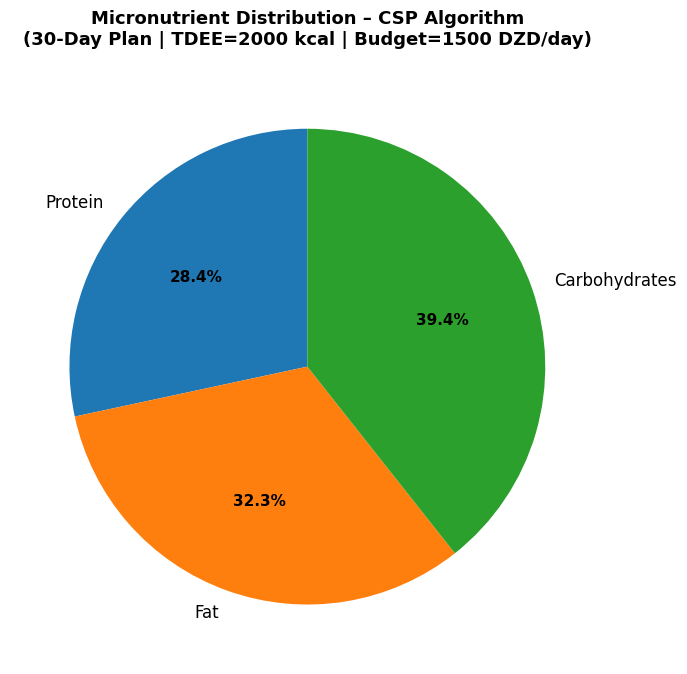

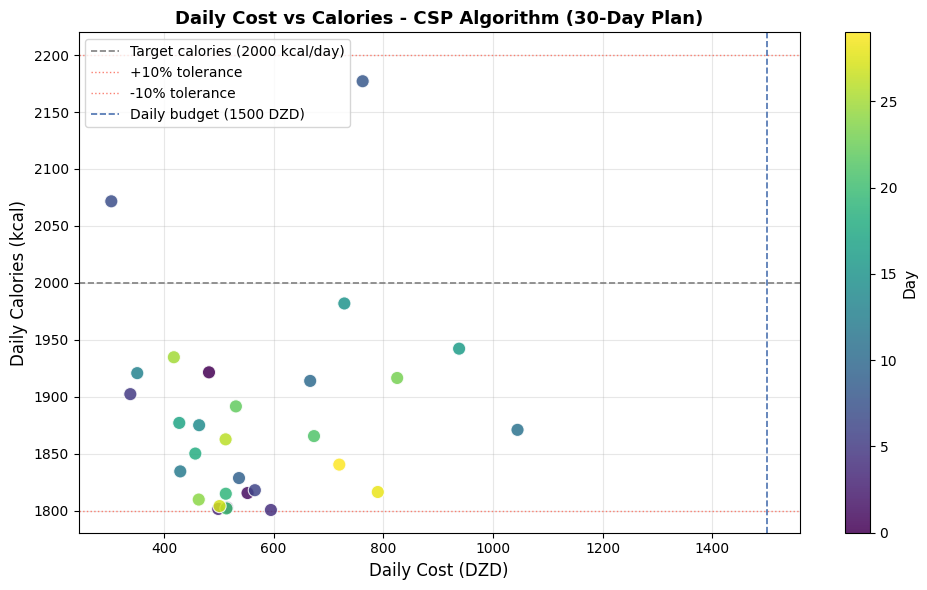

In [110]:
def csp_day_nutrition(plan, TransitionModel, DAYS):
    day_costs = []
    day_calories = []
    total_protein = total_fat = total_carbs = total_calories = 0

    for day in range(DAYS):
        bp = plan[day]["Breakfast"]
        lp = plan[day]["Lunch"]
        dp = plan[day]["Dinner"]

        b_info = TransitionModel["Breakfast"][bp]
        l_info = TransitionModel["Lunch"][lp]
        d_info = TransitionModel["Dinner"][dp]

        d_cost = b_info[1] + l_info[1] + d_info[1]
        d_kcal = b_info[2] + l_info[2] + d_info[2]
        d_prot = b_info[3] + l_info[3] + d_info[3]
        d_carb = b_info[4] + l_info[4] + d_info[4]
        d_fat  = b_info[5] + l_info[5] + d_info[5]

        day_costs.append(d_cost)
        day_calories.append(d_kcal)
        total_protein  += d_prot
        total_fat      += d_fat
        total_carbs    += d_carb
        total_calories += d_kcal

    return day_costs, day_calories, total_protein, total_fat, total_carbs, total_calories

day_costs, day_calories, total_protein, total_fat, total_carbs, total_calories =         csp_day_nutrition(plan, TransitionModel, DAYS)

# Pie Chart Micronutrient Distribution
fig, ax = plt.subplots(figsize=(7, 7))
labels  = ["Protein", "Fat", "Carbohydrates"]
values  = [total_protein, total_fat, total_carbs]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
explode = (0.04, 0.04, 0.04)

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12},
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")

ax.set_title(
    f"Micronutrient Distribution – CSP Algorithm\n"
    f"({DAYS}-Day Plan | TDEE={TDEE} kcal | Budget={DAILY_BUDGET} DZD/day)",
    fontsize=13, fontweight="bold", pad=18
)
plt.tight_layout()
plt.show()

# Scatter Plot Daily Cost vs Daily Calories 
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    day_costs, day_calories,
    c=range(DAYS), cmap="viridis",
    s=90, alpha=0.85, edgecolors="white", linewidths=0.8, zorder=3
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Day", fontsize=11)

# Reference lines
ax.axhline(TDEE,        color="gray",   linestyle="--", linewidth=1.2,
           label=f"Target calories ({TDEE} kcal/day)")
ax.axhline(TDEE * 1.1,  color="salmon", linestyle=":",  linewidth=1.0,
            label="+10% tolerance")
ax.axhline(TDEE * 0.9,  color="salmon", linestyle=":",  linewidth=1.0,
           label="-10% tolerance")
ax.axvline(DAILY_BUDGET, color="#4C72B0", linestyle="--", linewidth=1.2,
           label=f"Daily budget ({DAILY_BUDGET} DZD)")

ax.set_xlabel("Daily Cost (DZD)", fontsize=12)
ax.set_ylabel("Daily Calories (kcal)", fontsize=12)
ax.set_title(
    f"Daily Cost vs Calories - CSP Algorithm ({DAYS}-Day Plan)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


